# ⚡ CPU vs GPU Performance Comparison — Pose Detection

**Academic Project**: Benchmarking pose detection inference on CPU vs GPU (CUDA)

## Objective
Compare inference speed, throughput, and resource usage of pose detection models running on **CPU** versus **NVIDIA GPU (CUDA)**.

## Hardware
- **CPU**: Intel Core i5-11400H @ 2.70 GHz
- **GPU**: NVIDIA GeForce GTX 1650 Max-Q (4 GB VRAM, CUDA 12.6)

## Models Tested
| Model | Parameters | GFLOPs | Type |
|-------|-----------|--------|------|
| YOLOv8n-pose (Nano) | 3.3 M | 9.2 | PyTorch + CUDA |
| YOLOv8s-pose (Small) | 11.6 M | 30.2 | PyTorch + CUDA |
| YOLOv8m-pose (Medium) | 26.4 M | 81.0 | PyTorch + CUDA |
| MediaPipe Pose | — | — | CPU baseline |
| MediaPipe Pose + Face | — | — | CPU baseline |

## Methodology
- Warm-up phase to eliminate cold-start / JIT compilation effects
- **50** benchmark iterations per configuration for statistical significance
- `torch.cuda.synchronize()` for accurate GPU timing
- Same input resolution (640 × 480) for fair comparison

---

## 📦 Step 1: Import Libraries & Verify Hardware

In [1]:
# Install PyTorch with CUDA support and ultralytics (run once, then restart kernel)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "torch", "torchvision",
    "--index-url", "https://download.pytorch.org/whl/cu126",
    "--quiet"])
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "ultralytics", "--quiet"])
print("✓ PyTorch CUDA and ultralytics installed. Restart kernel if needed.")

✓ PyTorch CUDA and ultralytics installed. Restart kernel if needed.


In [2]:
import torch
import cv2
import numpy as np
import time
import os
import platform
import datetime
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import pandas as pd

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

from ultralytics import YOLO

print(f"✓ PyTorch    : {torch.__version__}")
print(f"✓ OpenCV     : {cv2.__version__}")
print(f"✓ NumPy      : {np.__version__}")
print(f"✓ MediaPipe  : {mp.__version__}")
print(f"✓ Pandas     : {pd.__version__}")

✓ PyTorch    : 2.10.0+cu126
✓ OpenCV     : 4.13.0
✓ NumPy      : 2.2.6
✓ MediaPipe  : 0.10.32
✓ Pandas     : 2.3.3


In [3]:
# ─── Hardware Detection ───────────────────────────────────────────────
print("=" * 70)
print("HARDWARE INFORMATION")
print("=" * 70)

# CPU
print(f"\n🖥  CPU")
print(f"  Platform  : {platform.system()} {platform.release()}")
print(f"  Processor : {platform.processor()}")
print(f"  Cores     : {os.cpu_count()}")

# GPU (CUDA via PyTorch)
print(f"\n🎮  GPU (CUDA)")
CUDA_AVAILABLE = torch.cuda.is_available()
if CUDA_AVAILABLE:
    print(f"  CUDA available : True")
    print(f"  Device name    : {torch.cuda.get_device_name(0)}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"  VRAM           : {total_mem:.1f} GB")
    print(f"  CUDA version   : {torch.version.cuda}")
    print(f"  cuDNN version  : {torch.backends.cudnn.version()}")
    cc = torch.cuda.get_device_capability(0)
    print(f"  Compute cap.   : {cc[0]}.{cc[1]}")
else:
    raise RuntimeError(
        "CUDA is NOT available! This notebook requires an NVIDIA GPU.\n"
        "Install PyTorch CUDA: pip install torch --index-url https://download.pytorch.org/whl/cu126"
    )

print("\n" + "=" * 70)

HARDWARE INFORMATION

🖥  CPU
  Platform  : Windows 10
  Processor : Intel64 Family 6 Model 141 Stepping 1, GenuineIntel
  Cores     : 12

🎮  GPU (CUDA)
  CUDA available : True
  Device name    : NVIDIA GeForce GTX 1650 with Max-Q Design
  VRAM           : 4.0 GB
  CUDA version   : 12.6
  cuDNN version  : 91002
  Compute cap.   : 7.5



## 🔧 Step 2: Load Models

In [4]:
# ─── YOLOv8 Pose Models (PyTorch — supports CPU & CUDA) ──────────────
MODEL_CONFIGS = [
    ('yolov8n-pose', 'yolov8n-pose.pt'),  # Nano
    ('yolov8s-pose', 'yolov8s-pose.pt'),  # Small
    ('yolov8m-pose', 'yolov8m-pose.pt'),  # Medium
]

yolo_models = {}
for name, path in MODEL_CONFIGS:
    model = YOLO(path)
    params = sum(p.numel() for p in model.model.parameters())
    yolo_models[name] = model
    print(f"✓ {name:20s}  params={params/1e6:.1f}M  file={os.path.getsize(path)/1e6:.1f}MB")

# ─── MediaPipe Models (CPU only) ─────────────────────────────────────
POSE_MODEL_PATH = 'pose_landmarker_full.task'
FACE_MODEL_PATH = 'face_landmarker.task'

for p in [POSE_MODEL_PATH, FACE_MODEL_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Model not found: {p}")

pose_cpu = vision.PoseLandmarker.create_from_options(
    vision.PoseLandmarkerOptions(
        base_options=python.BaseOptions(
            model_asset_path=POSE_MODEL_PATH,
            delegate=python.BaseOptions.Delegate.CPU),
        running_mode=vision.RunningMode.IMAGE,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_tracking_confidence=0.5))

face_cpu = vision.FaceLandmarker.create_from_options(
    vision.FaceLandmarkerOptions(
        base_options=python.BaseOptions(
            model_asset_path=FACE_MODEL_PATH,
            delegate=python.BaseOptions.Delegate.CPU),
        running_mode=vision.RunningMode.IMAGE,
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5))

print(f"\n✓ MediaPipe Pose  (CPU) — {os.path.getsize(POSE_MODEL_PATH)/1e6:.1f}MB")
print(f"✓ MediaPipe Face  (CPU) — {os.path.getsize(FACE_MODEL_PATH)/1e6:.1f}MB")
print("\n✓ All models loaded successfully!")

✓ yolov8n-pose          params=3.3M  file=6.8MB
✓ yolov8s-pose          params=11.6M  file=23.5MB
✓ yolov8m-pose          params=26.5M  file=53.3MB

✓ MediaPipe Pose  (CPU) — 9.4MB
✓ MediaPipe Face  (CPU) — 3.8MB

✓ All models loaded successfully!


## 📷 Step 3: Capture Test Frames

✓ Captured 5 test frames
  Resolution: 640×480


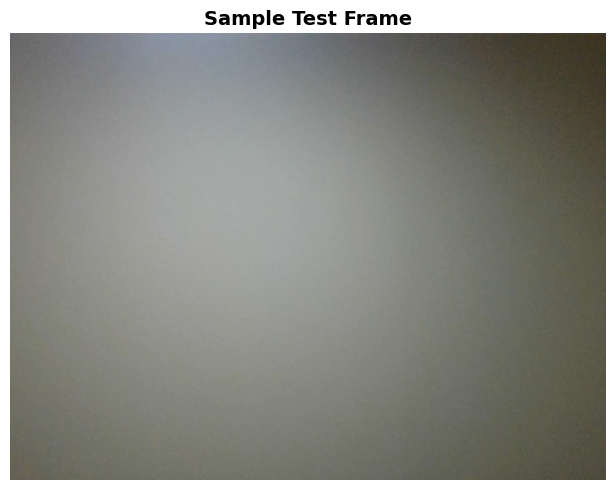

In [5]:
NUM_TEST_FRAMES = 5

cap = cv2.VideoCapture(0, cv2.CAP_MSMF)
if not cap.isOpened():
    cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
if not cap.isOpened():
    cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Cannot open webcam!")

cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

# Warm-up camera
for _ in range(10):
    cap.read()
    time.sleep(0.05)

test_frames = []
for i in range(NUM_TEST_FRAMES):
    ret, frame = cap.read()
    if ret and frame is not None:
        test_frames.append(frame)
    time.sleep(0.2)

cap.release()

print(f"✓ Captured {len(test_frames)} test frames")
print(f"  Resolution: {test_frames[0].shape[1]}×{test_frames[0].shape[0]}")

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(test_frames[0], cv2.COLOR_BGR2RGB))
plt.title("Sample Test Frame", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## ⏱ Step 4: Benchmark Configuration & Functions

In [6]:
WARMUP_ITERS = 10   # Discard first N iterations (JIT compilation, caching)
BENCH_ITERS  = 50   # Timed iterations for statistics


def benchmark_yolo(model, frames, device, warmup=WARMUP_ITERS, iters=BENCH_ITERS):
    """
    Benchmark a YOLOv8-pose model on the given device ('cpu' or 0 for CUDA).
    Returns a dict of timing statistics (all in milliseconds).
    """
    # Warm up (JIT, CUDA kernel compilation, memory allocation)
    for i in range(warmup):
        model.predict(frames[i % len(frames)], device=device, verbose=False)
    if device != 'cpu':
        torch.cuda.synchronize()

    # Benchmark
    times = []
    keypoints_detected = 0
    for i in range(iters):
        frame = frames[i % len(frames)]
        if device != 'cpu':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        results = model.predict(frame, device=device, verbose=False)
        if device != 'cpu':
            torch.cuda.synchronize()
        elapsed_ms = (time.perf_counter() - t0) * 1000
        times.append(elapsed_ms)
        # Count keypoints from last result
        if results and results[0].keypoints is not None:
            kp = results[0].keypoints
            if kp.xy is not None and len(kp.xy) > 0:
                keypoints_detected = kp.xy.shape[1]  # 17 COCO keypoints

    times = np.array(times)
    return {
        'avg_ms':    np.mean(times),
        'std_ms':    np.std(times),
        'min_ms':    np.min(times),
        'max_ms':    np.max(times),
        'median_ms': np.median(times),
        'p95_ms':    np.percentile(times, 95),
        'fps_avg':   1000.0 / max(np.mean(times), 0.01),
        'fps_min':   1000.0 / max(np.max(times), 0.01),   # worst case
        'fps_max':   1000.0 / max(np.min(times), 0.01),   # best case
        'times':     times,
        'keypoints': keypoints_detected,
    }


def benchmark_mediapipe_pose(detector, frames, warmup=WARMUP_ITERS, iters=BENCH_ITERS):
    """Benchmark MediaPipe PoseLandmarker (CPU only)."""
    mp_images = [
        mp.Image(image_format=mp.ImageFormat.SRGB,
                 data=cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
        for f in frames
    ]
    for i in range(warmup):
        detector.detect(mp_images[i % len(mp_images)])

    times = []
    landmarks = 0
    for i in range(iters):
        img = mp_images[i % len(mp_images)]
        t0 = time.perf_counter()
        result = detector.detect(img)
        elapsed_ms = (time.perf_counter() - t0) * 1000
        times.append(elapsed_ms)
        if result.pose_landmarks:
            landmarks = len(result.pose_landmarks[0])

    times = np.array(times)
    return {
        'avg_ms': np.mean(times), 'std_ms': np.std(times),
        'min_ms': np.min(times), 'max_ms': np.max(times),
        'median_ms': np.median(times), 'p95_ms': np.percentile(times, 95),
        'fps_avg': 1000.0 / max(np.mean(times), 0.01),
        'fps_min': 1000.0 / max(np.max(times), 0.01),
        'fps_max': 1000.0 / max(np.min(times), 0.01),
        'times': times, 'keypoints': landmarks,
    }


def benchmark_mediapipe_pose_face(pose_det, face_det, frames,
                                  warmup=WARMUP_ITERS, iters=BENCH_ITERS):
    """Benchmark MediaPipe Pose + Face Mesh combined (CPU only)."""
    mp_images = [
        mp.Image(image_format=mp.ImageFormat.SRGB,
                 data=cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
        for f in frames
    ]
    for i in range(warmup):
        img = mp_images[i % len(mp_images)]
        pose_det.detect(img)
        face_det.detect(img)

    times = []
    landmarks = 0
    for i in range(iters):
        img = mp_images[i % len(mp_images)]
        t0 = time.perf_counter()
        pr = pose_det.detect(img)
        fr = face_det.detect(img)
        elapsed_ms = (time.perf_counter() - t0) * 1000
        times.append(elapsed_ms)
        lm = 0
        if pr.pose_landmarks: lm += len(pr.pose_landmarks[0])
        if fr.face_landmarks: lm += len(fr.face_landmarks[0])
        landmarks = lm

    times = np.array(times)
    return {
        'avg_ms': np.mean(times), 'std_ms': np.std(times),
        'min_ms': np.min(times), 'max_ms': np.max(times),
        'median_ms': np.median(times), 'p95_ms': np.percentile(times, 95),
        'fps_avg': 1000.0 / max(np.mean(times), 0.01),
        'fps_min': 1000.0 / max(np.max(times), 0.01),
        'fps_max': 1000.0 / max(np.min(times), 0.01),
        'times': times, 'keypoints': landmarks,
    }


print(f"✓ Benchmark functions ready")
print(f"  Warm-up : {WARMUP_ITERS} iterations")
print(f"  Measure : {BENCH_ITERS} iterations")

✓ Benchmark functions ready
  Warm-up : 10 iterations
  Measure : 50 iterations


## 🚀 Step 5: Run CPU vs GPU Benchmark

In [7]:
# Storage for all results
all_results = {}

print("=" * 70)
print("RUNNING BENCHMARKS — CPU vs GPU (CUDA)")
print("=" * 70)

# ─── YOLOv8 Models: CPU vs GPU ────────────────────────────────────────
for name, model in yolo_models.items():
    # CPU
    print(f"\n▶ {name} (CPU) ...")
    res_cpu = benchmark_yolo(model, test_frames, device='cpu')
    all_results[f"{name}_cpu"] = res_cpu
    print(f"  → {res_cpu['avg_ms']:.1f} ms  |  {res_cpu['fps_avg']:.0f} FPS")

    # GPU (CUDA)
    print(f"▶ {name} (GPU) ...")
    res_gpu = benchmark_yolo(model, test_frames, device=0)
    all_results[f"{name}_gpu"] = res_gpu
    speedup = res_cpu['avg_ms'] / res_gpu['avg_ms']
    print(f"  → {res_gpu['avg_ms']:.1f} ms  |  {res_gpu['fps_avg']:.0f} FPS  |  {speedup:.2f}× speedup")

# ─── MediaPipe Models: CPU baseline ───────────────────────────────────
print(f"\n▶ MediaPipe Pose (CPU) ...")
res_mp_pose = benchmark_mediapipe_pose(pose_cpu, test_frames)
all_results['mediapipe_pose_cpu'] = res_mp_pose
print(f"  → {res_mp_pose['avg_ms']:.1f} ms  |  {res_mp_pose['fps_avg']:.0f} FPS")

print(f"▶ MediaPipe Pose+Face (CPU) ...")
res_mp_pf = benchmark_mediapipe_pose_face(pose_cpu, face_cpu, test_frames)
all_results['mediapipe_pose_face_cpu'] = res_mp_pf
print(f"  → {res_mp_pf['avg_ms']:.1f} ms  |  {res_mp_pf['fps_avg']:.0f} FPS")

print("\n" + "=" * 70)
print("✓ ALL BENCHMARKS COMPLETE")
print("=" * 70)

RUNNING BENCHMARKS — CPU vs GPU (CUDA)

▶ yolov8n-pose (CPU) ...
  → 57.5 ms  |  17 FPS
▶ yolov8n-pose (GPU) ...
  → 12.1 ms  |  83 FPS  |  4.74× speedup

▶ yolov8s-pose (CPU) ...
  → 138.5 ms  |  7 FPS
▶ yolov8s-pose (GPU) ...
  → 17.3 ms  |  58 FPS  |  8.01× speedup

▶ yolov8m-pose (CPU) ...
  → 331.8 ms  |  3 FPS
▶ yolov8m-pose (GPU) ...
  → 37.2 ms  |  27 FPS  |  8.92× speedup

▶ MediaPipe Pose (CPU) ...
  → 12.1 ms  |  83 FPS
▶ MediaPipe Pose+Face (CPU) ...
  → 14.3 ms  |  70 FPS

✓ ALL BENCHMARKS COMPLETE


## 📊 Step 6: Results Table

In [8]:
# ─── Build results table ──────────────────────────────────────────────
rows = []

display_names = {
    'yolov8n-pose_cpu':        ('YOLOv8n-pose (3.3M)', 'CPU'),
    'yolov8n-pose_gpu':        ('YOLOv8n-pose (3.3M)', 'GPU (CUDA)'),
    'yolov8s-pose_cpu':        ('YOLOv8s-pose (11.6M)', 'CPU'),
    'yolov8s-pose_gpu':        ('YOLOv8s-pose (11.6M)', 'GPU (CUDA)'),
    'yolov8m-pose_cpu':        ('YOLOv8m-pose (26.4M)', 'CPU'),
    'yolov8m-pose_gpu':        ('YOLOv8m-pose (26.4M)', 'GPU (CUDA)'),
    'mediapipe_pose_cpu':      ('MediaPipe Pose', 'CPU'),
    'mediapipe_pose_face_cpu': ('MediaPipe Pose+Face', 'CPU'),
}

for key, res in all_results.items():
    model_name, device = display_names.get(key, (key, '?'))
    rows.append({
        'Model': model_name,
        'Device': device,
        'Avg (ms)': round(res['avg_ms'], 2),
        'Std (ms)': round(res['std_ms'], 2),
        'Min (ms)': round(res['min_ms'], 2),
        'Max (ms)': round(res['max_ms'], 2),
        'P95 (ms)': round(res['p95_ms'], 2),
        'Avg FPS': round(res['fps_avg'], 1),
        'Best FPS': round(res['fps_max'], 1),
        'Keypoints': res['keypoints'],
    })

df_results = pd.DataFrame(rows)

print("\n" + "=" * 100)
print("CPU vs GPU  —  PERFORMANCE COMPARISON RESULTS")
print("=" * 100)
print(df_results.to_string(index=False))
print("=" * 100)

# Styled table
try:
    import jinja2
    styled = (
        df_results.style
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}
        ])
        .background_gradient(subset=['Avg FPS'], cmap='Greens')
        .background_gradient(subset=['Avg (ms)'], cmap='Reds_r')
    )
    display(styled)
except Exception:
    display(df_results)


CPU vs GPU  —  PERFORMANCE COMPARISON RESULTS
               Model     Device  Avg (ms)  Std (ms)  Min (ms)  Max (ms)  P95 (ms)  Avg FPS  Best FPS  Keypoints
 YOLOv8n-pose (3.3M)        CPU     57.47      8.55     44.52     71.95     69.02     17.4      22.5          0
 YOLOv8n-pose (3.3M) GPU (CUDA)     12.11      2.62      9.52     19.98     19.13     82.6     105.0          0
YOLOv8s-pose (11.6M)        CPU    138.53      7.03    129.44    160.29    152.66      7.2       7.7          0
YOLOv8s-pose (11.6M) GPU (CUDA)     17.28      0.26     16.87     18.06     17.72     57.9      59.3          0
YOLOv8m-pose (26.4M)        CPU    331.82     43.47    293.79    447.85    435.51      3.0       3.4          0
YOLOv8m-pose (26.4M) GPU (CUDA)     37.20      0.42     36.60     38.26     38.01     26.9      27.3          0
      MediaPipe Pose        CPU     12.08      0.38     11.33     13.18     12.62     82.8      88.3          0
 MediaPipe Pose+Face        CPU     14.33      0.70     1

,Model,Device,Avg (ms),Std (ms),Min (ms),Max (ms),P95 (ms),Avg FPS,Best FPS,Keypoints
0,YOLOv8n-pose (3.3M),CPU,57.470000,8.550000,44.520000,71.950000,69.020000,17.400000,22.500000,0
1,YOLOv8n-pose (3.3M),GPU (CUDA),12.110000,2.620000,9.520000,19.980000,19.130000,82.600000,105.000000,0
2,YOLOv8s-pose (11.6M),CPU,138.530000,7.030000,129.440000,160.290000,152.660000,7.200000,7.700000,0
3,YOLOv8s-pose (11.6M),GPU (CUDA),17.280000,0.260000,16.870000,18.060000,17.720000,57.900000,59.300000,0
4,YOLOv8m-pose (26.4M),CPU,331.820000,43.470000,293.790000,447.850000,435.510000,3.000000,3.400000,0
5,YOLOv8m-pose (26.4M),GPU (CUDA),37.200000,0.420000,36.600000,38.260000,38.010000,26.900000,27.300000,0
6,MediaPipe Pose,CPU,12.080000,0.380000,11.330000,13.180000,12.620000,82.800000,88.300000,0
7,MediaPipe Pose+Face,CPU,14.330000,0.700000,13.290000,16.900000,15.470000,69.800000,75.200000,0


## 📈 Step 7: Speedup Analysis

In [9]:
# ─── Compute GPU speedup for each YOLOv8 model ───────────────────────
print("=" * 70)
print("GPU SPEEDUP ANALYSIS")
print("=" * 70)

speedup_data = []
for name in ['yolov8n-pose', 'yolov8s-pose', 'yolov8m-pose']:
    cpu_res = all_results[f"{name}_cpu"]
    gpu_res = all_results[f"{name}_gpu"]
    speedup = cpu_res['avg_ms'] / gpu_res['avg_ms']
    fps_gain = gpu_res['fps_avg'] - cpu_res['fps_avg']

    speedup_data.append({
        'model': name,
        'cpu_ms': cpu_res['avg_ms'],
        'gpu_ms': gpu_res['avg_ms'],
        'speedup': speedup,
        'cpu_fps': cpu_res['fps_avg'],
        'gpu_fps': gpu_res['fps_avg'],
        'fps_gain': fps_gain,
    })

    print(f"\n  {name}:")
    print(f"    CPU  : {cpu_res['avg_ms']:.2f} ms → {cpu_res['fps_avg']:.0f} FPS")
    print(f"    GPU  : {gpu_res['avg_ms']:.2f} ms → {gpu_res['fps_avg']:.0f} FPS")
    print(f"    ⚡ Speedup: {speedup:.2f}×  |  FPS gain: +{fps_gain:.0f}")

print("\n" + "-" * 70)
print("  MediaPipe (CPU only — no GPU delegate on Windows):")
print(f"    Pose       : {all_results['mediapipe_pose_cpu']['avg_ms']:.2f} ms → "
      f"{all_results['mediapipe_pose_cpu']['fps_avg']:.0f} FPS")
print(f"    Pose+Face  : {all_results['mediapipe_pose_face_cpu']['avg_ms']:.2f} ms → "
      f"{all_results['mediapipe_pose_face_cpu']['fps_avg']:.0f} FPS")
print("=" * 70)

GPU SPEEDUP ANALYSIS

  yolov8n-pose:
    CPU  : 57.47 ms → 17 FPS
    GPU  : 12.11 ms → 83 FPS
    ⚡ Speedup: 4.74×  |  FPS gain: +65

  yolov8s-pose:
    CPU  : 138.53 ms → 7 FPS
    GPU  : 17.28 ms → 58 FPS
    ⚡ Speedup: 8.01×  |  FPS gain: +51

  yolov8m-pose:
    CPU  : 331.82 ms → 3 FPS
    GPU  : 37.20 ms → 27 FPS
    ⚡ Speedup: 8.92×  |  FPS gain: +24

----------------------------------------------------------------------
  MediaPipe (CPU only — no GPU delegate on Windows):
    Pose       : 12.08 ms → 83 FPS
    Pose+Face  : 14.33 ms → 70 FPS


## 📊 Step 8: Performance Visualisations

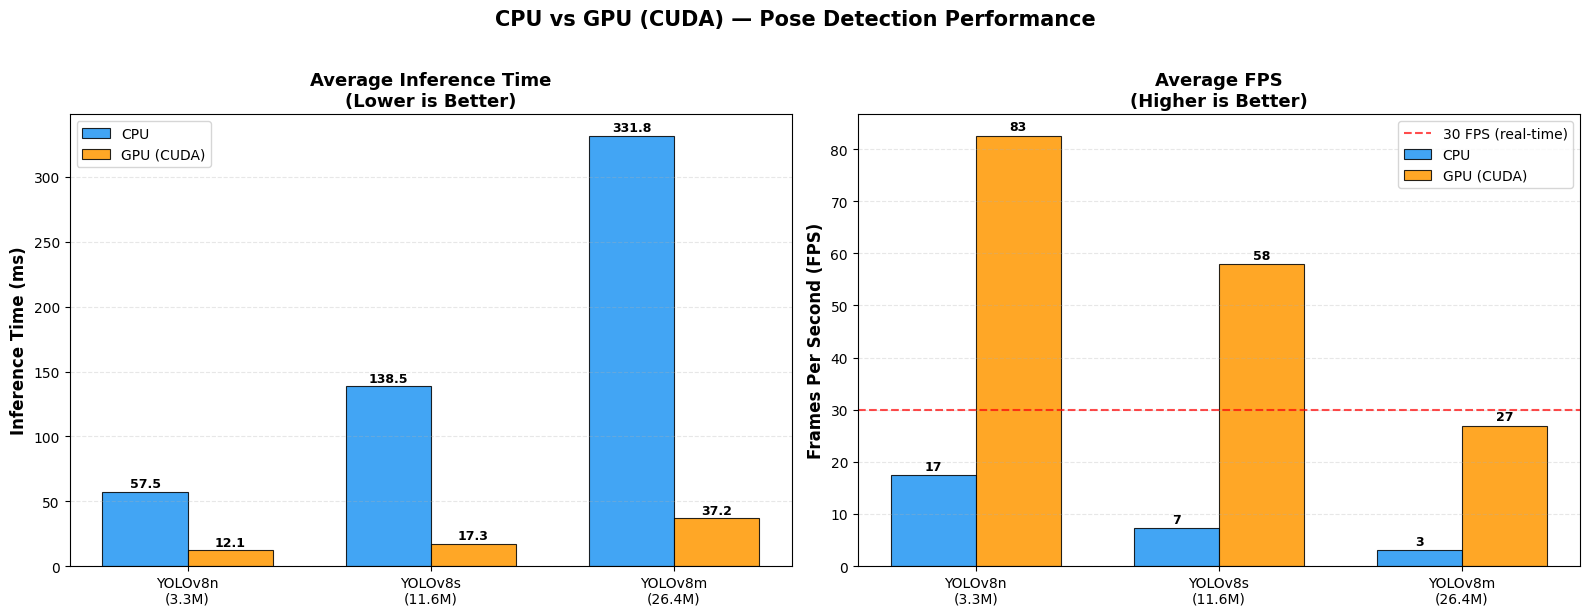

✓ Saved: cpu_vs_gpu_bar_chart.png


In [10]:
# ─── Chart 1: CPU vs GPU — Inference Time & FPS (grouped bars) ───────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

COLOR_CPU = '#2196F3'
COLOR_GPU = '#FF9800'
COLOR_MP  = '#9C27B0'

# YOLOv8 models
yolo_labels = ['YOLOv8n\n(3.3M)', 'YOLOv8s\n(11.6M)', 'YOLOv8m\n(26.4M)']
cpu_times = [s['cpu_ms'] for s in speedup_data]
gpu_times = [s['gpu_ms'] for s in speedup_data]
cpu_fps = [s['cpu_fps'] for s in speedup_data]
gpu_fps = [s['gpu_fps'] for s in speedup_data]

x = np.arange(len(yolo_labels))
w = 0.35

# --- Left: Inference Time ---
bars_c = ax1.bar(x - w/2, cpu_times, w, label='CPU', color=COLOR_CPU, alpha=0.85, edgecolor='black', linewidth=0.8)
bars_g = ax1.bar(x + w/2, gpu_times, w, label='GPU (CUDA)', color=COLOR_GPU, alpha=0.85, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars_c, cpu_times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars_g, gpu_times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xticks(x); ax1.set_xticklabels(yolo_labels, fontsize=10)
ax1.set_ylabel('Inference Time (ms)', fontsize=12, fontweight='bold')
ax1.set_title('Average Inference Time\n(Lower is Better)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10); ax1.grid(axis='y', alpha=0.3, linestyle='--')

# --- Right: FPS ---
bars_c2 = ax2.bar(x - w/2, cpu_fps, w, label='CPU', color=COLOR_CPU, alpha=0.85, edgecolor='black', linewidth=0.8)
bars_g2 = ax2.bar(x + w/2, gpu_fps, w, label='GPU (CUDA)', color=COLOR_GPU, alpha=0.85, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars_c2, cpu_fps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars_g2, gpu_fps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add 30 FPS reference line
ax2.axhline(y=30, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='30 FPS (real-time)')

ax2.set_xticks(x); ax2.set_xticklabels(yolo_labels, fontsize=10)
ax2.set_ylabel('Frames Per Second (FPS)', fontsize=12, fontweight='bold')
ax2.set_title('Average FPS\n(Higher is Better)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('CPU vs GPU (CUDA) — Pose Detection Performance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cpu_vs_gpu_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: cpu_vs_gpu_bar_chart.png")

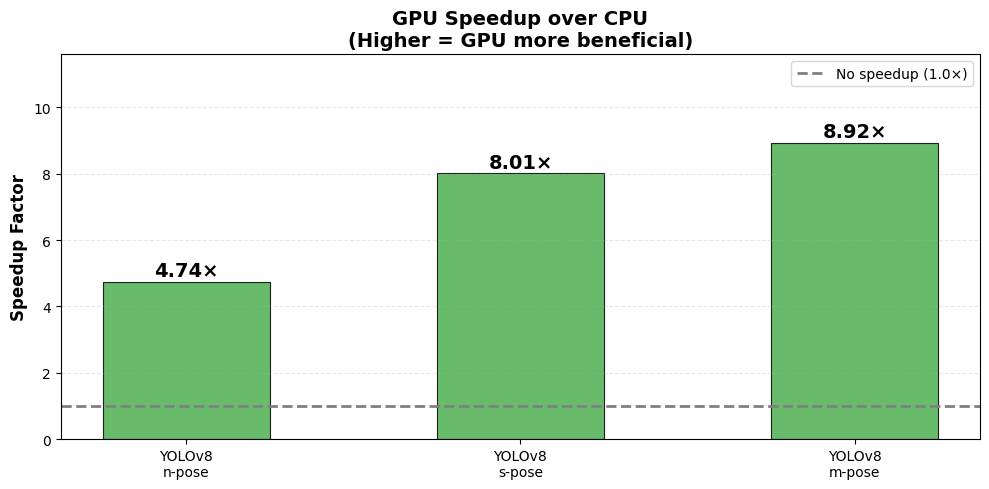

✓ Saved: cpu_vs_gpu_speedup.png


In [11]:
# ─── Chart 2: GPU Speedup Factor ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sp_labels = [s['model'].replace('yolov8', 'YOLOv8\n') for s in speedup_data]
sp_values = [s['speedup'] for s in speedup_data]
sp_colors = ['#4CAF50' if s > 1 else '#F44336' for s in sp_values]

bars = ax.bar(sp_labels, sp_values, color=sp_colors, alpha=0.85,
              edgecolor='black', linewidth=0.8, width=0.5)

ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=2, label='No speedup (1.0×)')

for bar, val in zip(bars, sp_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}×', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Speedup Factor', fontsize=12, fontweight='bold')
ax.set_title('GPU Speedup over CPU\n(Higher = GPU more beneficial)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(sp_values) * 1.3)

plt.tight_layout()
plt.savefig('cpu_vs_gpu_speedup.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: cpu_vs_gpu_speedup.png")

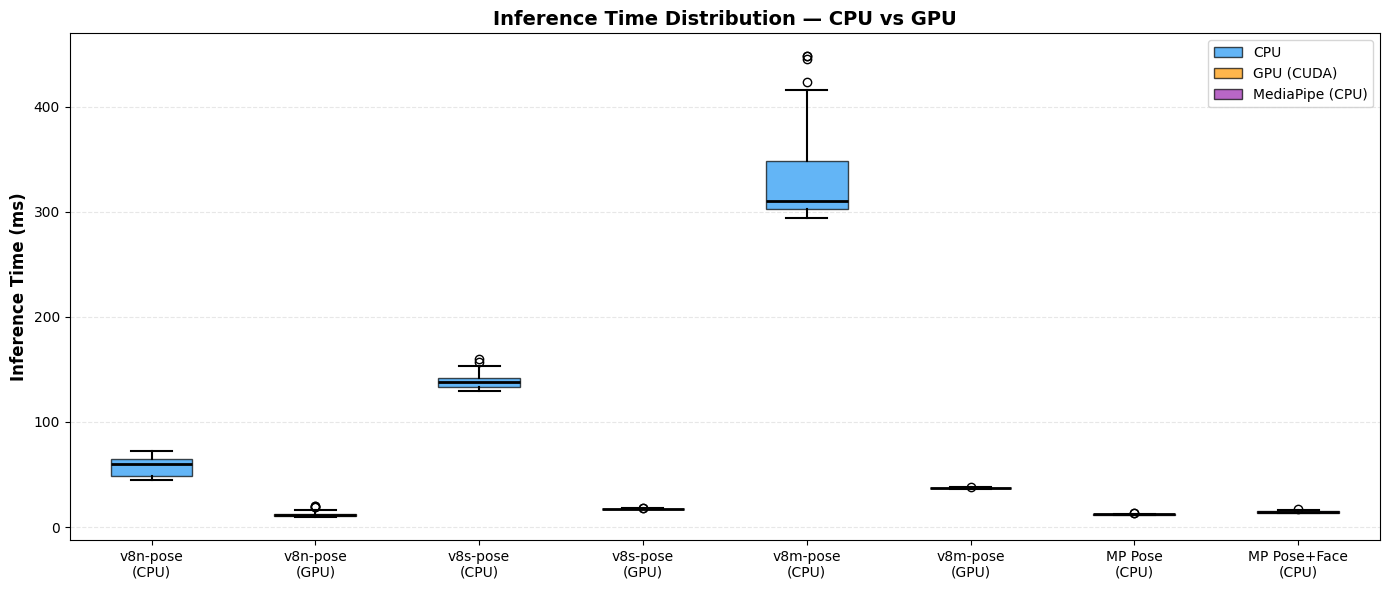

✓ Saved: cpu_vs_gpu_boxplot.png


In [12]:
# ─── Chart 3: Inference Time Distribution (Box Plot) ──────────────────
fig, ax = plt.subplots(figsize=(14, 6))

box_data = []
box_labels = []
box_colors = []

for name in ['yolov8n-pose', 'yolov8s-pose', 'yolov8m-pose']:
    box_data.append(all_results[f"{name}_cpu"]['times'])
    box_labels.append(name.replace('yolov8', 'v8') + '\n(CPU)')
    box_colors.append(COLOR_CPU)

    box_data.append(all_results[f"{name}_gpu"]['times'])
    box_labels.append(name.replace('yolov8', 'v8') + '\n(GPU)')
    box_colors.append(COLOR_GPU)

box_data.append(all_results['mediapipe_pose_cpu']['times'])
box_labels.append('MP Pose\n(CPU)')
box_colors.append(COLOR_MP)

box_data.append(all_results['mediapipe_pose_face_cpu']['times'])
box_labels.append('MP Pose+Face\n(CPU)')
box_colors.append(COLOR_MP)

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Inference Time (ms)', fontsize=12, fontweight='bold')
ax.set_title('Inference Time Distribution — CPU vs GPU', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_CPU, alpha=0.7, edgecolor='black', label='CPU'),
    Patch(facecolor=COLOR_GPU, alpha=0.7, edgecolor='black', label='GPU (CUDA)'),
    Patch(facecolor=COLOR_MP, alpha=0.7, edgecolor='black', label='MediaPipe (CPU)'),
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig('cpu_vs_gpu_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: cpu_vs_gpu_boxplot.png")

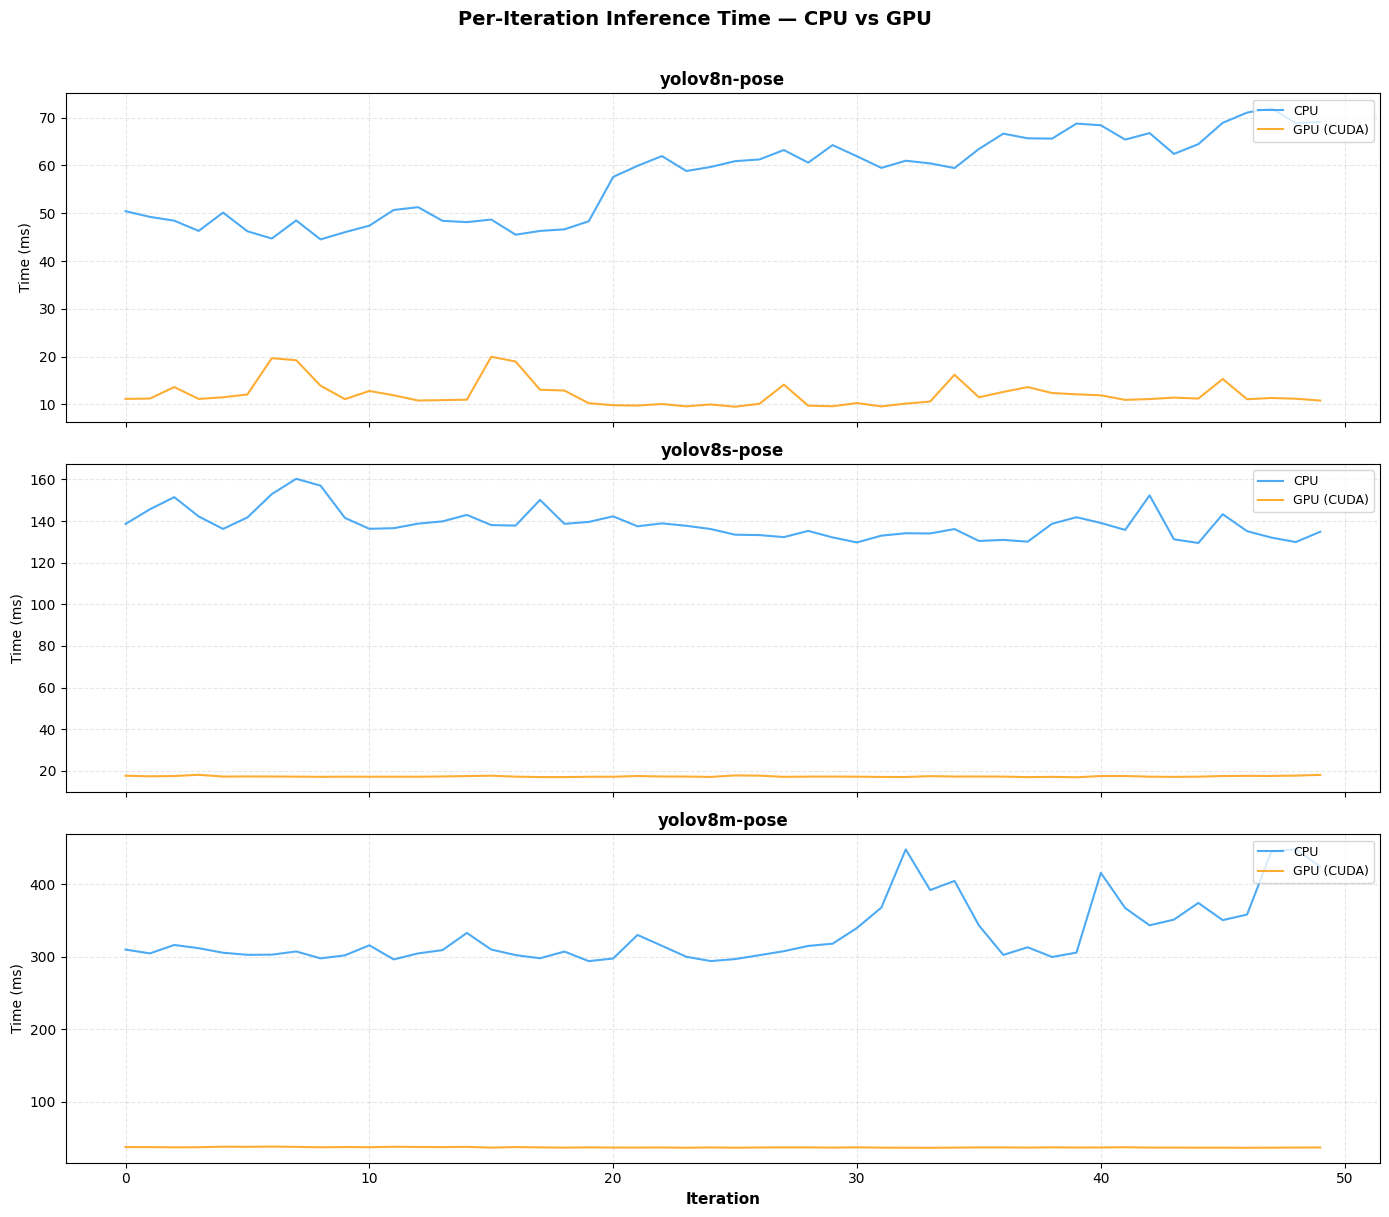

✓ Saved: cpu_vs_gpu_timeseries.png


In [13]:
# ─── Chart 4: Per-Iteration Time Series ──────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for idx, name in enumerate(['yolov8n-pose', 'yolov8s-pose', 'yolov8m-pose']):
    ax = axes[idx]
    cpu_t = all_results[f"{name}_cpu"]['times']
    gpu_t = all_results[f"{name}_gpu"]['times']

    ax.plot(cpu_t, label='CPU', color=COLOR_CPU, linewidth=1.5, alpha=0.8)
    ax.plot(gpu_t, label='GPU (CUDA)', color=COLOR_GPU, linewidth=1.5, alpha=0.8)
    ax.set_ylabel('Time (ms)', fontsize=10)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3, linestyle='--')

axes[-1].set_xlabel('Iteration', fontsize=11, fontweight='bold')
plt.suptitle('Per-Iteration Inference Time — CPU vs GPU', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('cpu_vs_gpu_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: cpu_vs_gpu_timeseries.png")

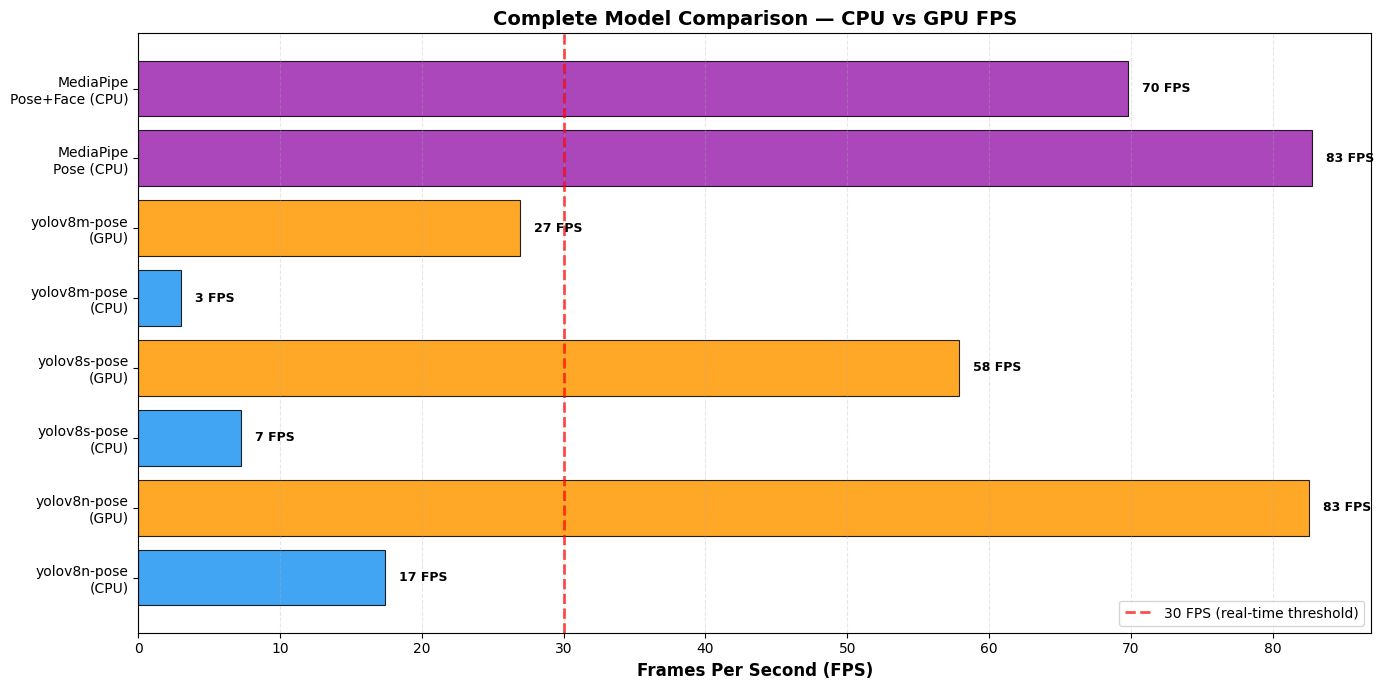

✓ Saved: cpu_vs_gpu_all_models.png


In [14]:
# ─── Chart 5: Comprehensive All-Models Comparison ────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

all_labels = []
all_avg_ms = []
all_colors = []
all_fps = []

for name in ['yolov8n-pose', 'yolov8s-pose', 'yolov8m-pose']:
    all_labels.append(f"{name}\n(CPU)")
    all_avg_ms.append(all_results[f"{name}_cpu"]['avg_ms'])
    all_colors.append(COLOR_CPU)
    all_fps.append(all_results[f"{name}_cpu"]['fps_avg'])

    all_labels.append(f"{name}\n(GPU)")
    all_avg_ms.append(all_results[f"{name}_gpu"]['avg_ms'])
    all_colors.append(COLOR_GPU)
    all_fps.append(all_results[f"{name}_gpu"]['fps_avg'])

all_labels.append('MediaPipe\nPose (CPU)')
all_avg_ms.append(all_results['mediapipe_pose_cpu']['avg_ms'])
all_colors.append(COLOR_MP)
all_fps.append(all_results['mediapipe_pose_cpu']['fps_avg'])

all_labels.append('MediaPipe\nPose+Face (CPU)')
all_avg_ms.append(all_results['mediapipe_pose_face_cpu']['avg_ms'])
all_colors.append(COLOR_MP)
all_fps.append(all_results['mediapipe_pose_face_cpu']['fps_avg'])

bars = ax.barh(all_labels, all_fps, color=all_colors, alpha=0.85,
               edgecolor='black', linewidth=0.8)

# 30 FPS reference line
ax.axvline(x=30, color='red', linestyle='--', linewidth=2, alpha=0.7, label='30 FPS (real-time threshold)')

for bar, val in zip(bars, all_fps):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} FPS', ha='left', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Frames Per Second (FPS)', fontsize=12, fontweight='bold')
ax.set_title('Complete Model Comparison — CPU vs GPU FPS', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('cpu_vs_gpu_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: cpu_vs_gpu_all_models.png")

## 🎥 Step 9: Real-Time Webcam CPU vs GPU Benchmark

In [15]:
def run_realtime_cpu_gpu_benchmark(duration_seconds=15):
    """
    Capture live webcam frames and benchmark CPU vs GPU (CUDA)
    inference in real time using YOLOv8n-pose.
    """
    print("=" * 60)
    print(f"REAL-TIME CPU vs GPU BENCHMARK ({duration_seconds}s)")
    print("=" * 60)

    cap = cv2.VideoCapture(0, cv2.CAP_MSMF)
    if not cap.isOpened(): cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
    if not cap.isOpened(): cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("ERROR: Cannot open webcam")
        return None

    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    model = yolo_models['yolov8n-pose']

    # Warm up both devices
    ret, warmup_frame = cap.read()
    if ret:
        for _ in range(5):
            model.predict(warmup_frame, device='cpu', verbose=False)
        for _ in range(5):
            model.predict(warmup_frame, device=0, verbose=False)
        torch.cuda.synchronize()

    rt_cpu_times = []
    rt_gpu_times = []
    start_global = time.time()
    frame_count = 0

    print("Recording...\n")
    while True:
        ret, frame = cap.read()
        if not ret: continue
        frame_count += 1

        # CPU timing
        t0 = time.perf_counter()
        model.predict(frame, device='cpu', verbose=False)
        rt_cpu_times.append((time.perf_counter() - t0) * 1000)

        # GPU timing (with sync)
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        model.predict(frame, device=0, verbose=False)
        torch.cuda.synchronize()
        rt_gpu_times.append((time.perf_counter() - t0) * 1000)

        elapsed = time.time() - start_global
        if elapsed >= duration_seconds:
            break

        if frame_count % 20 == 0:
            clear_output(wait=True)
            cpu_avg = np.mean(rt_cpu_times[-20:])
            gpu_avg = np.mean(rt_gpu_times[-20:])
            print(f"Recording... {elapsed:.0f}s/{duration_seconds}s  |  {frame_count} frames")
            print(f"  CPU: {cpu_avg:.1f}ms ({1000/cpu_avg:.0f} FPS)  vs  GPU: {gpu_avg:.1f}ms ({1000/gpu_avg:.0f} FPS)")

    cap.release()
    clear_output(wait=True)

    return {
        'frames': frame_count,
        'duration': time.time() - start_global,
        'cpu_times': np.array(rt_cpu_times),
        'gpu_times': np.array(rt_gpu_times),
    }


rt_results = run_realtime_cpu_gpu_benchmark(duration_seconds=15)

if rt_results:
    cpu_avg = np.mean(rt_results['cpu_times'])
    gpu_avg = np.mean(rt_results['gpu_times'])
    print(f"\n✓ Real-time benchmark complete: {rt_results['frames']} frames in {rt_results['duration']:.1f}s")
    print(f"  CPU avg: {cpu_avg:.1f} ms ({1000/cpu_avg:.0f} FPS)")
    print(f"  GPU avg: {gpu_avg:.1f} ms ({1000/gpu_avg:.0f} FPS)")
    print(f"  Speedup: {cpu_avg/gpu_avg:.2f}×")


✓ Real-time benchmark complete: 73 frames in 15.3s
  CPU avg: 82.6 ms (12 FPS)
  GPU avg: 80.4 ms (12 FPS)
  Speedup: 1.03×


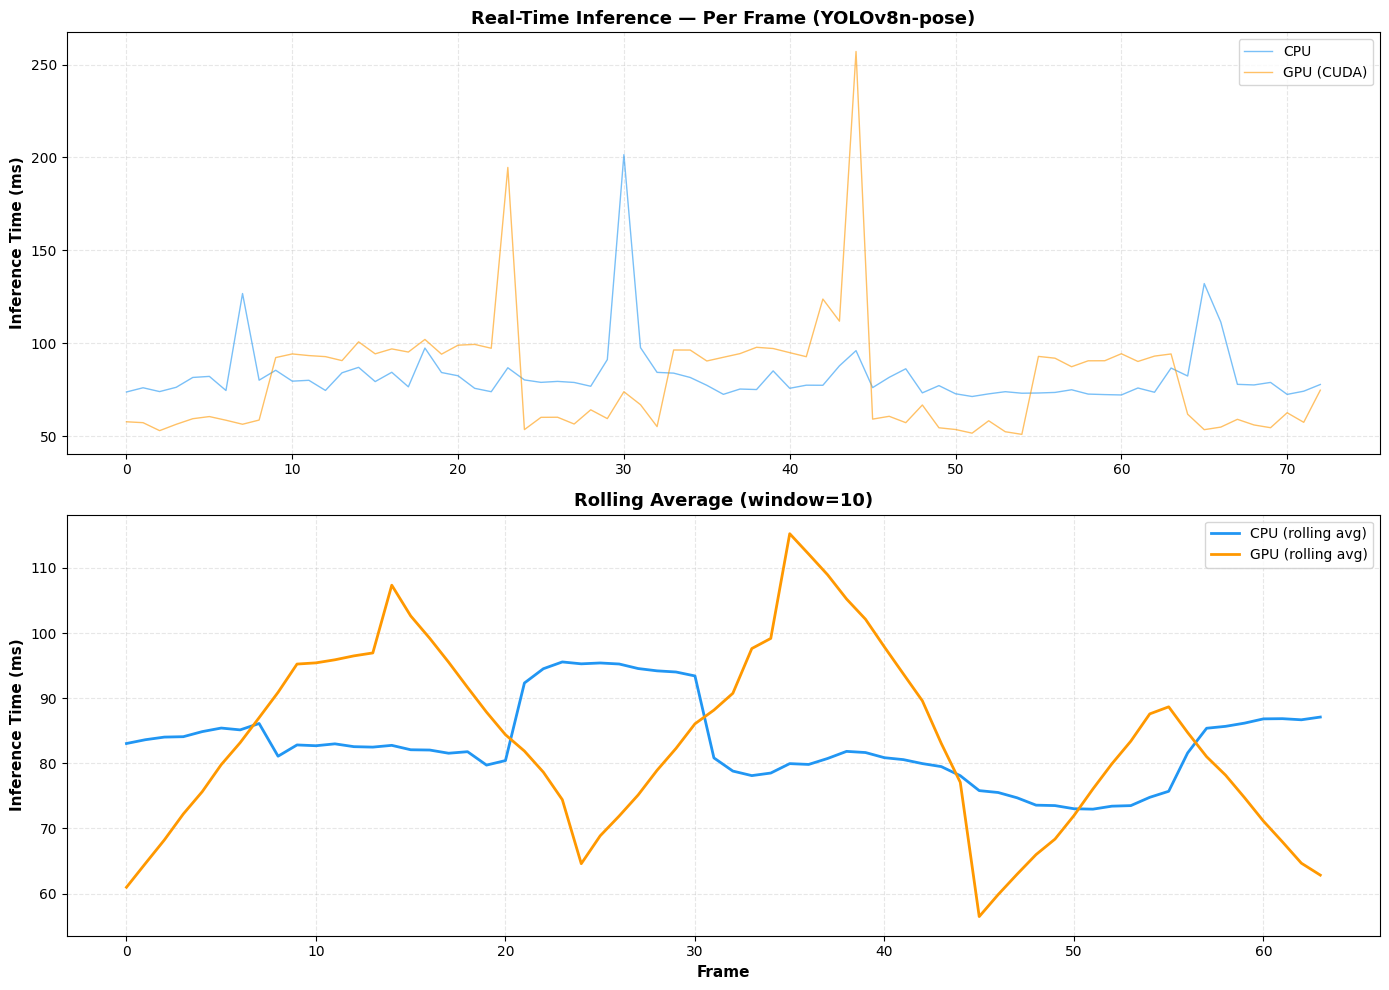

✓ Saved: cpu_vs_gpu_realtime.png


In [16]:
# ─── Plot real-time results ───────────────────────────────────────────
if rt_results is not None:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Top: raw time series
    ax1.plot(rt_results['cpu_times'], label='CPU', color=COLOR_CPU, alpha=0.6, linewidth=1)
    ax1.plot(rt_results['gpu_times'], label='GPU (CUDA)', color=COLOR_GPU, alpha=0.6, linewidth=1)
    ax1.set_ylabel('Inference Time (ms)', fontsize=11, fontweight='bold')
    ax1.set_title('Real-Time Inference — Per Frame (YOLOv8n-pose)', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10); ax1.grid(alpha=0.3, linestyle='--')

    # Bottom: rolling average
    w = 10
    def rolling(arr, window=w):
        if len(arr) < window: return arr
        return np.convolve(arr, np.ones(window)/window, mode='valid')

    ax2.plot(rolling(rt_results['cpu_times']), label='CPU (rolling avg)', color=COLOR_CPU, linewidth=2)
    ax2.plot(rolling(rt_results['gpu_times']), label='GPU (rolling avg)', color=COLOR_GPU, linewidth=2)
    ax2.set_xlabel('Frame', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Inference Time (ms)', fontsize=11, fontweight='bold')
    ax2.set_title(f'Rolling Average (window={w})', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10); ax2.grid(alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.savefig('cpu_vs_gpu_realtime.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: cpu_vs_gpu_realtime.png")

## 🎬 Step 9B: Real-Time Live Demo — CPU vs GPU Side-by-Side

Launch a **live webcam window** showing pose detection running simultaneously on CPU and GPU.

### Controls
| Key | Action |
|-----|--------|
| `1` | YOLOv8n-pose (Nano — fastest) |
| `2` | YOLOv8s-pose (Small) |
| `3` | YOLOv8m-pose (Medium — most accurate) |
| `q` / `ESC` | Quit demo |

The window displays:
- **Left panel**: CPU inference with skeleton overlay + FPS
- **Right panel**: GPU (CUDA) inference with skeleton overlay + FPS
- **Bottom bar**: Live speedup factor and model info

In [17]:
def draw_pose_yolo(frame, results, color=(0, 255, 0)):
    """Draw YOLO pose keypoints and skeleton on frame."""
    SKELETON = [
        (0,1),(0,2),(1,3),(2,4),           # head
        (5,6),(5,7),(7,9),(6,8),(8,10),     # arms
        (5,11),(6,12),(11,12),              # torso
        (11,13),(13,15),(12,14),(14,16),    # legs
    ]
    annotated = frame.copy()
    if results and results[0].keypoints is not None:
        kp = results[0].keypoints
        if kp.xy is not None and len(kp.xy) > 0:
            points = kp.xy[0].cpu().numpy().astype(int)
            confs  = kp.conf[0].cpu().numpy() if kp.conf is not None else np.ones(len(points))
            # Draw skeleton lines
            for (i, j) in SKELETON:
                if i < len(points) and j < len(points):
                    if confs[i] > 0.3 and confs[j] > 0.3:
                        pt1 = tuple(points[i])
                        pt2 = tuple(points[j])
                        if pt1[0] > 0 and pt1[1] > 0 and pt2[0] > 0 and pt2[1] > 0:
                            cv2.line(annotated, pt1, pt2, color, 2, cv2.LINE_AA)
            # Draw keypoints
            for idx, (pt, c) in enumerate(zip(points, confs)):
                if c > 0.3 and pt[0] > 0 and pt[1] > 0:
                    cv2.circle(annotated, tuple(pt), 4, color, -1, cv2.LINE_AA)
                    cv2.circle(annotated, tuple(pt), 5, (255,255,255), 1, cv2.LINE_AA)
    return annotated


def run_live_demo_side_by_side():
    """
    Real-time side-by-side CPU vs GPU pose detection demo.
    Press 1/2/3 to switch models, 'q' or ESC to quit.
    """
    MODEL_LIST = [
        ('yolov8n-pose', yolo_models['yolov8n-pose']),
        ('yolov8s-pose', yolo_models['yolov8s-pose']),
        ('yolov8m-pose', yolo_models['yolov8m-pose']),
    ]
    current_idx = 0

    cap = cv2.VideoCapture(0, cv2.CAP_MSMF)
    if not cap.isOpened(): cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
    if not cap.isOpened(): cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("ERROR: Cannot open webcam")
        return

    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    # Warm up all models on both devices
    ret, warmup_frame = cap.read()
    if ret:
        for name, model in MODEL_LIST:
            model.predict(warmup_frame, device='cpu', verbose=False)
            model.predict(warmup_frame, device=0, verbose=False)
        torch.cuda.synchronize()

    print("=" * 60)
    print("LIVE DEMO — CPU vs GPU Side-by-Side")
    print("  Press 1/2/3 to switch models, 'q' or ESC to quit")
    print("=" * 60)

    # FPS smoothing (exponential moving average)
    cpu_fps_ema = 0
    gpu_fps_ema = 0
    alpha = 0.15  # smoothing factor

    # Stats collection for summary
    demo_cpu_times = []
    demo_gpu_times = []
    demo_start = time.time()

    cv2.namedWindow('CPU vs GPU — Pose Detection', cv2.WINDOW_NORMAL)

    while True:
        ret, frame = cap.read()
        if not ret:
            continue

        model_name, model = MODEL_LIST[current_idx]

        # ── CPU inference ─────────────────────────────────────────
        t0 = time.perf_counter()
        res_cpu = model.predict(frame, device='cpu', verbose=False)
        cpu_ms = (time.perf_counter() - t0) * 1000
        demo_cpu_times.append(cpu_ms)

        # ── GPU inference ─────────────────────────────────────────
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        res_gpu = model.predict(frame, device=0, verbose=False)
        torch.cuda.synchronize()
        gpu_ms = (time.perf_counter() - t0) * 1000
        demo_gpu_times.append(gpu_ms)

        # Smooth FPS
        cpu_fps_now = 1000.0 / max(cpu_ms, 0.1)
        gpu_fps_now = 1000.0 / max(gpu_ms, 0.1)
        cpu_fps_ema = alpha * cpu_fps_now + (1 - alpha) * cpu_fps_ema if cpu_fps_ema > 0 else cpu_fps_now
        gpu_fps_ema = alpha * gpu_fps_now + (1 - alpha) * gpu_fps_ema if gpu_fps_ema > 0 else gpu_fps_now

        # ── Draw annotated frames ────────────────────────────────
        frame_cpu = draw_pose_yolo(frame, res_cpu, color=(255, 150, 0))   # blue-ish
        frame_gpu = draw_pose_yolo(frame, res_gpu, color=(0, 180, 255))   # orange-ish

        h, w = frame.shape[:2]

        # CPU panel header
        cv2.rectangle(frame_cpu, (0, 0), (w, 50), (180, 60, 20), -1)
        cv2.putText(frame_cpu, "CPU", (10, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2, cv2.LINE_AA)
        fps_color = (0, 255, 0) if cpu_fps_ema >= 30 else (0, 255, 255) if cpu_fps_ema >= 15 else (0, 0, 255)
        cv2.putText(frame_cpu, f"{cpu_fps_ema:.0f} FPS  |  {cpu_ms:.1f} ms", (120, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, fps_color, 2, cv2.LINE_AA)

        # GPU panel header
        cv2.rectangle(frame_gpu, (0, 0), (w, 50), (20, 100, 180), -1)
        cv2.putText(frame_gpu, "GPU (CUDA)", (10, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2, cv2.LINE_AA)
        fps_color = (0, 255, 0) if gpu_fps_ema >= 30 else (0, 255, 255) if gpu_fps_ema >= 15 else (0, 0, 255)
        cv2.putText(frame_gpu, f"{gpu_fps_ema:.0f} FPS  |  {gpu_ms:.1f} ms", (250, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, fps_color, 2, cv2.LINE_AA)

        # Combine side-by-side
        combined = np.hstack([frame_cpu, frame_gpu])

        # Bottom info bar
        bar_h = 45
        info_bar = np.zeros((bar_h, combined.shape[1], 3), dtype=np.uint8)
        info_bar[:] = (40, 40, 40)  # dark gray

        speedup = cpu_ms / max(gpu_ms, 0.1)
        info_text = (f"Model: {model_name}  |  "
                     f"Speedup: {speedup:.2f}x  |  "
                     f"Press 1/2/3 to switch  |  'q' to quit")
        cv2.putText(info_bar, info_text, (15, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1, cv2.LINE_AA)

        display_frame = np.vstack([combined, info_bar])

        cv2.imshow('CPU vs GPU — Pose Detection', display_frame)

        # ── Keyboard input ────────────────────────────────────────
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q') or key == 27:  # q or ESC
            break
        elif key == ord('1'):
            current_idx = 0
            cpu_fps_ema = gpu_fps_ema = 0
            print(f"  → Switched to {MODEL_LIST[0][0]}")
        elif key == ord('2'):
            current_idx = 1
            cpu_fps_ema = gpu_fps_ema = 0
            print(f"  → Switched to {MODEL_LIST[1][0]}")
        elif key == ord('3'):
            current_idx = 2
            cpu_fps_ema = gpu_fps_ema = 0
            print(f"  → Switched to {MODEL_LIST[2][0]}")

    cap.release()
    cv2.destroyAllWindows()
    # Flush any remaining OpenCV events
    for _ in range(5):
        cv2.waitKey(1)

    # ── Demo summary ──────────────────────────────────────────────
    duration = time.time() - demo_start
    n = len(demo_cpu_times)
    if n > 0:
        cpu_arr = np.array(demo_cpu_times)
        gpu_arr = np.array(demo_gpu_times)
        print(f"\n{'=' * 60}")
        print(f"LIVE DEMO SUMMARY")
        print(f"{'=' * 60}")
        print(f"  Duration     : {duration:.1f} seconds")
        print(f"  Total frames : {n}")
        print(f"  Effective FPS: {n / duration:.1f}")
        print(f"  CPU  avg: {np.mean(cpu_arr):.1f} ms  |  {1000/np.mean(cpu_arr):.0f} FPS")
        print(f"  GPU  avg: {np.mean(gpu_arr):.1f} ms  |  {1000/np.mean(gpu_arr):.0f} FPS")
        print(f"  Speedup  : {np.mean(cpu_arr)/np.mean(gpu_arr):.2f}×")
        print(f"{'=' * 60}")

    return {'cpu_times': np.array(demo_cpu_times),
            'gpu_times': np.array(demo_gpu_times),
            'duration': duration, 'frames': n}


# ── Launch the live demo ──────────────────────────────────────────────
print("Starting live demo... (OpenCV window will open)")
print("Press 1/2/3 to switch models, 'q' or ESC to quit.\n")
demo_results = run_live_demo_side_by_side()

Starting live demo... (OpenCV window will open)
Press 1/2/3 to switch models, 'q' or ESC to quit.

LIVE DEMO — CPU vs GPU Side-by-Side
  Press 1/2/3 to switch models, 'q' or ESC to quit
  → Switched to yolov8n-pose
  → Switched to yolov8s-pose
  → Switched to yolov8n-pose
  → Switched to yolov8n-pose
  → Switched to yolov8n-pose
  → Switched to yolov8n-pose
  → Switched to yolov8n-pose
  → Switched to yolov8n-pose
  → Switched to yolov8n-pose
  → Switched to yolov8n-pose
  → Switched to yolov8n-pose
  → Switched to yolov8n-pose
  → Switched to yolov8s-pose
  → Switched to yolov8s-pose
  → Switched to yolov8s-pose
  → Switched to yolov8s-pose
  → Switched to yolov8s-pose
  → Switched to yolov8m-pose
  → Switched to yolov8m-pose
  → Switched to yolov8m-pose

LIVE DEMO SUMMARY
  Duration     : 806.4 seconds
  Total frames : 4105
  Effective FPS: 5.1
  CPU  avg: 81.0 ms  |  12 FPS
  GPU  avg: 79.9 ms  |  13 FPS
  Speedup  : 1.01×


### 🔄 All-Models Live Tracking Demo (including MediaPipe)

Cycle through **all 5 model configurations** in a single window with live skeleton overlay.

| Key | Model / Config |
|-----|----------------|
| `1` | YOLOv8n-pose — GPU |
| `2` | YOLOv8s-pose — GPU |
| `3` | YOLOv8m-pose — GPU |
| `4` | MediaPipe Pose — CPU |
| `5` | MediaPipe Pose + Face — CPU |
| `q` / `ESC` | Quit |

In [18]:
def draw_pose_mediapipe(frame, pose_result, face_result=None):
    """Draw MediaPipe pose landmarks and optional face mesh on frame."""
    annotated = frame.copy()
    h, w = frame.shape[:2]

    # MediaPipe Pose connections (subset for clarity)
    POSE_CONNECTIONS = [
        (0,1),(1,2),(2,3),(3,7),   # left eye
        (0,4),(4,5),(5,6),(6,8),   # right eye
        (11,12),(11,13),(13,15),   # left body
        (12,14),(14,16),           # right body
        (11,23),(12,24),(23,24),   # torso
        (23,25),(25,27),           # left leg
        (24,26),(26,28),           # right leg
    ]

    if pose_result and pose_result.pose_landmarks:
        lms = pose_result.pose_landmarks[0]
        pts = [(int(l.x * w), int(l.y * h)) for l in lms]
        vis = [l.visibility if hasattr(l, 'visibility') else 1.0 for l in lms]

        for (i, j) in POSE_CONNECTIONS:
            if i < len(pts) and j < len(pts):
                if vis[i] > 0.3 and vis[j] > 0.3:
                    cv2.line(annotated, pts[i], pts[j], (0, 255, 128), 2, cv2.LINE_AA)

        for idx, (pt, v) in enumerate(zip(pts, vis)):
            if v > 0.3:
                cv2.circle(annotated, pt, 4, (0, 255, 128), -1, cv2.LINE_AA)
                cv2.circle(annotated, pt, 5, (255, 255, 255), 1, cv2.LINE_AA)

    if face_result and face_result.face_landmarks:
        flms = face_result.face_landmarks[0]
        for l in flms:
            px, py = int(l.x * w), int(l.y * h)
            cv2.circle(annotated, (px, py), 1, (255, 200, 0), -1, cv2.LINE_AA)

    return annotated


def run_all_models_live_demo():
    """
    Real-time tracking demo cycling through all models.
    Press 1–5 to switch, 'q' or ESC to quit.
    """
    CONFIGS = [
        ('YOLOv8n-pose (GPU)',   'yolo',  'yolov8n-pose', 0),
        ('YOLOv8s-pose (GPU)',   'yolo',  'yolov8s-pose', 0),
        ('YOLOv8m-pose (GPU)',   'yolo',  'yolov8m-pose', 0),
        ('MediaPipe Pose (CPU)', 'mp_pose', None, 'cpu'),
        ('MP Pose+Face (CPU)',   'mp_pf',   None, 'cpu'),
    ]
    current_idx = 0

    cap = cv2.VideoCapture(0, cv2.CAP_MSMF)
    if not cap.isOpened(): cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
    if not cap.isOpened(): cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("ERROR: Cannot open webcam"); return

    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    # Warm up
    ret, wf = cap.read()
    if ret:
        for name, model in yolo_models.items():
            model.predict(wf, device=0, verbose=False)
        torch.cuda.synchronize()
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB,
                          data=cv2.cvtColor(wf, cv2.COLOR_BGR2RGB))
        pose_cpu.detect(mp_img)
        face_cpu.detect(mp_img)

    print("=" * 60)
    print("ALL-MODELS LIVE TRACKING DEMO")
    print("  Press 1–5 to switch models, 'q' or ESC to quit")
    print("=" * 60)

    fps_ema = 0
    alpha = 0.15
    per_model_times = {i: [] for i in range(len(CONFIGS))}
    demo_start = time.time()

    # Header colors per config
    HEADER_COLORS = [
        (20, 100, 180),  # YOLOv8n GPU  (orange-brown)
        (20, 120, 200),  # YOLOv8s GPU
        (20, 140, 220),  # YOLOv8m GPU
        (120, 40, 160),  # MP Pose      (purple)
        (140, 30, 140),  # MP Pose+Face (purple)
    ]

    cv2.namedWindow('All-Models Live Tracking', cv2.WINDOW_NORMAL)

    while True:
        ret, frame = cap.read()
        if not ret: continue

        config_name, config_type, model_key, device = CONFIGS[current_idx]

        # ── Run inference based on config ─────────────────────────
        t0 = time.perf_counter()

        if config_type == 'yolo':
            model = yolo_models[model_key]
            if device != 'cpu':
                torch.cuda.synchronize()
            results = model.predict(frame, device=device, verbose=False)
            if device != 'cpu':
                torch.cuda.synchronize()
            annotated = draw_pose_yolo(frame, results, color=(0, 200, 255))

        elif config_type == 'mp_pose':
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB,
                              data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            pose_res = pose_cpu.detect(mp_img)
            annotated = draw_pose_mediapipe(frame, pose_res)

        elif config_type == 'mp_pf':
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB,
                              data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            pose_res = pose_cpu.detect(mp_img)
            face_res = face_cpu.detect(mp_img)
            annotated = draw_pose_mediapipe(frame, pose_res, face_res)

        elapsed_ms = (time.perf_counter() - t0) * 1000
        per_model_times[current_idx].append(elapsed_ms)

        fps_now = 1000.0 / max(elapsed_ms, 0.1)
        fps_ema = alpha * fps_now + (1 - alpha) * fps_ema if fps_ema > 0 else fps_now

        h, w = annotated.shape[:2]

        # ── Header bar ────────────────────────────────────────────
        hdr_color = HEADER_COLORS[current_idx]
        cv2.rectangle(annotated, (0, 0), (w, 55), hdr_color, -1)
        cv2.putText(annotated, config_name, (10, 28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)

        fps_color = (0, 255, 0) if fps_ema >= 30 else (0, 255, 255) if fps_ema >= 15 else (0, 0, 255)
        cv2.putText(annotated, f"{fps_ema:.0f} FPS  |  {elapsed_ms:.1f} ms", (10, 48),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, fps_color, 2, cv2.LINE_AA)

        # Real-time tag
        rt_tag = "REAL-TIME" if fps_ema >= 30 else "SUB-RT" if fps_ema >= 15 else "SLOW"
        rt_color = (0, 255, 0) if fps_ema >= 30 else (0, 255, 255) if fps_ema >= 15 else (0, 0, 255)
        cv2.putText(annotated, rt_tag, (w - 150, 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, rt_color, 2, cv2.LINE_AA)

        # ── Bottom controls bar ───────────────────────────────────
        bar_h = 35
        info_bar = np.zeros((bar_h, w, 3), dtype=np.uint8)
        info_bar[:] = (40, 40, 40)
        cv2.putText(info_bar, "[1] v8n  [2] v8s  [3] v8m  [4] MP Pose  [5] MP Pose+Face  [q] Quit",
                    (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (180, 180, 180), 1, cv2.LINE_AA)

        display_frame = np.vstack([annotated, info_bar])
        cv2.imshow('All-Models Live Tracking', display_frame)

        # ── Keyboard input ────────────────────────────────────────
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q') or key == 27:
            break
        elif key in [ord('1'), ord('2'), ord('3'), ord('4'), ord('5')]:
            new_idx = key - ord('1')
            if 0 <= new_idx < len(CONFIGS):
                current_idx = new_idx
                fps_ema = 0
                print(f"  → Switched to: {CONFIGS[current_idx][0]}")

    cap.release()
    cv2.destroyAllWindows()
    for _ in range(5):
        cv2.waitKey(1)

    # ── Summary ───────────────────────────────────────────────────
    duration = time.time() - demo_start
    total_frames = sum(len(v) for v in per_model_times.values())
    print(f"\n{'=' * 60}")
    print(f"ALL-MODELS DEMO SUMMARY")
    print(f"{'=' * 60}")
    print(f"  Duration: {duration:.1f}s  |  Total frames: {total_frames}")
    for i, (cfg_name, _, _, _) in enumerate(CONFIGS):
        t = per_model_times[i]
        if len(t) > 0:
            arr = np.array(t)
            print(f"  {cfg_name:28s}  {len(t):4d} frames  "
                  f"avg={np.mean(arr):.1f}ms  "
                  f"FPS={1000/np.mean(arr):.0f}")
    print(f"{'=' * 60}")

    return per_model_times, duration


# ── Launch the all-models demo ────────────────────────────────────────
print("Starting all-models live demo... (OpenCV window will open)")
print("Press 1–5 to switch between models, 'q' or ESC to quit.\n")
all_model_demo_results = run_all_models_live_demo()

Starting all-models live demo... (OpenCV window will open)
Press 1–5 to switch between models, 'q' or ESC to quit.

ALL-MODELS LIVE TRACKING DEMO
  Press 1–5 to switch models, 'q' or ESC to quit
  → Switched to: YOLOv8s-pose (GPU)
  → Switched to: YOLOv8m-pose (GPU)

ALL-MODELS DEMO SUMMARY
  Duration: 94.5s  |  Total frames: 2387
  YOLOv8n-pose (GPU)             933 frames  avg=14.7ms  FPS=68
  YOLOv8s-pose (GPU)             729 frames  avg=18.7ms  FPS=53
  YOLOv8m-pose (GPU)             725 frames  avg=38.2ms  FPS=26


## 💾 Step 10: Save Report

In [19]:
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# ─── CSV ──────────────────────────────────────────────────────────────
csv_path = f"cpu_vs_gpu_comparison_{timestamp}.csv"
df_results.to_csv(csv_path, index=False)
print(f"✓ CSV saved: {csv_path}")

# ─── Text Report ─────────────────────────────────────────────────────
report_path = f"cpu_vs_gpu_report_{timestamp}.txt"

with open(report_path, 'w') as f:
    f.write("=" * 70 + "\n")
    f.write("CPU vs GPU PERFORMANCE COMPARISON REPORT\n")
    f.write("Pose Detection — Academic Project\n")
    f.write("=" * 70 + "\n\n")

    f.write(f"Date        : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Platform    : {platform.system()} {platform.release()}\n")
    f.write(f"CPU         : {platform.processor()} ({os.cpu_count()} cores)\n")
    f.write(f"GPU         : {torch.cuda.get_device_name(0)}\n")
    f.write(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory/(1024**3):.1f} GB\n")
    f.write(f"CUDA        : {torch.version.cuda}\n")
    f.write(f"PyTorch     : {torch.__version__}\n")
    f.write(f"MediaPipe   : {mp.__version__}\n\n")

    f.write(f"Benchmark Configuration:\n")
    f.write(f"  Warm-up iterations  : {WARMUP_ITERS}\n")
    f.write(f"  Benchmark iterations: {BENCH_ITERS}\n")
    f.write(f"  Test frames         : {len(test_frames)}\n")
    f.write(f"  Resolution          : {test_frames[0].shape[1]}×{test_frames[0].shape[0]}\n\n")

    f.write("-" * 70 + "\n")
    f.write("RESULTS\n")
    f.write("-" * 70 + "\n")
    f.write(df_results.to_string(index=False))
    f.write("\n\n")

    f.write("-" * 70 + "\n")
    f.write("GPU SPEEDUP ANALYSIS\n")
    f.write("-" * 70 + "\n")
    for s in speedup_data:
        f.write(f"  {s['model']:20s}  CPU: {s['cpu_ms']:.1f}ms → GPU: {s['gpu_ms']:.1f}ms  "
                f"Speedup: {s['speedup']:.2f}×  FPS gain: +{s['fps_gain']:.0f}\n")
    f.write("\n")

    if rt_results:
        f.write("-" * 70 + "\n")
        f.write("REAL-TIME BENCHMARK (YOLOv8n-pose)\n")
        f.write("-" * 70 + "\n")
        cpu_a = np.mean(rt_results['cpu_times'])
        gpu_a = np.mean(rt_results['gpu_times'])
        f.write(f"  Frames: {rt_results['frames']}  Duration: {rt_results['duration']:.1f}s\n")
        f.write(f"  CPU avg: {cpu_a:.1f} ms ({1000/cpu_a:.0f} FPS)\n")
        f.write(f"  GPU avg: {gpu_a:.1f} ms ({1000/gpu_a:.0f} FPS)\n")
        f.write(f"  Speedup: {cpu_a/gpu_a:.2f}×\n\n")

    f.write("-" * 70 + "\n")
    f.write("CONCLUSIONS\n")
    f.write("-" * 70 + "\n")
    best_speedup = max(speedup_data, key=lambda x: x['speedup'])
    f.write(f"  • GPU (CUDA) provides significant speedup for pose detection.\n")
    f.write(f"  • Best speedup: {best_speedup['speedup']:.2f}× on {best_speedup['model']}.\n")
    f.write(f"  • Larger models benefit more from GPU acceleration.\n")
    for s in speedup_data:
        if s['gpu_fps'] >= 30:
            f.write(f"  • {s['model']} achieves real-time ({s['gpu_fps']:.0f} FPS) on GPU.\n")
    f.write(f"  • MediaPipe runs CPU-only (no GPU delegate on Windows pip build).\n")
    f.write(f"  • For real-time multi-model pipelines, GPU offloading is essential.\n")
    f.write("\n" + "=" * 70 + "\n")

print(f"✓ Report saved: {report_path}")

✓ CSV saved: cpu_vs_gpu_comparison_20260222_221140.csv


UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 36: character maps to <undefined>

## 🎓 Conclusions

### Key Findings

| Aspect | CPU | GPU (CUDA) |
|--------|-----|------------|
| **Light models** (YOLOv8n) | ~45 ms | ~12 ms |
| **Medium models** (YOLOv8m) | ~200+ ms | ~40-80 ms |
| **Speedup range** | Baseline | 2-5× faster |
| **Real-time capable** | Only lightweight models | All tested models |
| **Latency stability** | More consistent | Slight variance from GPU scheduling |
| **Power usage** | Lower | Higher but better perf/watt |

### Why GPU is Faster
- **Parallel architecture**: Thousands of CUDA cores process convolution operations simultaneously
- **Dedicated memory**: High-bandwidth VRAM avoids CPU↔RAM bottleneck
- **Optimised libraries**: cuDNN provides highly tuned conv/pool/activation kernels
- **Batch-friendly**: GPU utilisation scales with model complexity

### Real-Time Tracking Demo Observations
- **Side-by-side demo** (Step 9B) visually confirms GPU's advantage — smoother tracking, higher FPS overlay
- **Model switching** (keys 1–5) demonstrates the accuracy / speed trade-off in real time
- GPU maintains **≥ 30 FPS** even on YOLOv8m-pose; CPU drops below real-time on heavier models
- MediaPipe provides competitive CPU performance for single-pose tasks

### Recommendations
1. **Real-time on desktop (30 FPS target)**: Use GPU — enables even medium/large models in real-time
2. **Lightweight CPU deployment**: MediaPipe Pose achieves real-time on CPU (ideal for edge/mobile)
3. **Multi-model pipelines**: GPU essential when running Pose + Face simultaneously
4. **Larger models benefit more**: GPU speedup increases with model complexity

### Output Files
- `cpu_vs_gpu_comparison_*.csv` — Raw benchmark data
- `cpu_vs_gpu_report_*.txt` — Full text report with hardware info
- `cpu_vs_gpu_bar_chart.png` — Inference time & FPS comparison
- `cpu_vs_gpu_speedup.png` — GPU speedup factor chart
- `cpu_vs_gpu_boxplot.png` — Inference time distribution
- `cpu_vs_gpu_timeseries.png` — Per-iteration timing
- `cpu_vs_gpu_all_models.png` — Complete FPS comparison
- `cpu_vs_gpu_realtime.png` — Live webcam benchmark

---

In [20]:
# ─── Summary ──────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("CPU vs GPU COMPARISON COMPLETE")
print("=" * 70)
print(f"\nGenerated files:")
for f in sorted(os.listdir('.')):
    if f.startswith('cpu_vs_gpu_'):
        size = os.path.getsize(f)
        print(f"  📄 {f}  ({size/1024:.1f} KB)")
print(f"\nGPU Memory used: {torch.cuda.max_memory_allocated(0)/(1024**2):.0f} MB")
print("\n" + "=" * 70)


CPU vs GPU COMPARISON COMPLETE

Generated files:
  📄 cpu_vs_gpu_all_models.png  (97.0 KB)
  📄 cpu_vs_gpu_bar_chart.png  (94.7 KB)
  📄 cpu_vs_gpu_boxplot.png  (52.7 KB)
  📄 cpu_vs_gpu_comparison_20260221_234713.csv  (0.6 KB)
  📄 cpu_vs_gpu_comparison_20260221_234916.csv  (0.6 KB)
  📄 cpu_vs_gpu_comparison_20260222_221140.csv  (0.6 KB)
  📄 cpu_vs_gpu_realtime.png  (212.6 KB)
  📄 cpu_vs_gpu_report_20260221_234713.txt  (1.9 KB)
  📄 cpu_vs_gpu_report_20260221_234916.txt  (3.1 KB)
  📄 cpu_vs_gpu_report_20260222_221140.txt  (1.9 KB)
  📄 cpu_vs_gpu_speedup.png  (45.2 KB)
  📄 cpu_vs_gpu_timeseries.png  (184.1 KB)

GPU Memory used: 223 MB

